In [ ]:
# Colab setup — skip if running locally
import importlib
pkgs = []
if importlib.util.find_spec('cvxpy') is None: pkgs.append('cvxpy')
if importlib.util.find_spec('torch') is None: pkgs.append('torch')
if pkgs:
    !pip install -q {' '.join(pkgs)}

# Lasso problem

The Lasso (Least Absolute Shrinkage and Selection Operator) is a regularized linear regression method that performs both variable selection and regularization. The Lasso problem can be formulated as follows:

\begin{equation*}
\min_{\mathbf{w}} \frac{1}{2 n } \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \lambda \|\mathbf{w}\|_1
\end{equation*}

where $\mathbf{X} \in \mathbb{R}^{n \times p}$ is the design matrix, $\mathbf{y} \in \mathbb{R}^n$ is the response vector, $\mathbf{w} \in \mathbb{R}^p$ is the weight vector, and $\lambda > 0$ is the regularization parameter. The $\ell_1$-norm regularization term $\|\mathbf{w}\|_1$ promotes sparsity in the weight vector $\mathbf{w}$.

# Optimization Algorithms:

## Subgradient Descent:

Subgradient descent is an iterative optimization algorithm for minimizing a non-differentiable convex function. For the Lasso problem, the subgradient of the objective function at $\mathbf{w}^t$ is given by:
\begin{equation*}
\mathbf{g}^t = \frac{1}{ n }\mathbf{X}^T(\mathbf{X}\mathbf{w}^t - \mathbf{y}) + \lambda \cdot \text{sign}(\mathbf{w}^t)
\end{equation*}

The update rule for subgradient descent is:

\begin{equation*}
\mathbf{w}^{t+1} = \mathbf{w}^t - \alpha^t \mathbf{g}^t
\end{equation*}

where $\alpha^t > 0$ is the step size at iteration $t$.

## Proximal Gradient Descent:

Proximal gradient descent is an optimization algorithm that can handle non-smooth regularization terms. The Lasso problem can be split into a smooth part $f(\mathbf{w}) = \frac{1}{2} |\mathbf{X}\mathbf{w} - \mathbf{y}|_2^2$ and a non-smooth part $g(\mathbf{w}) = \lambda \|\mathbf{w}\|_1$. The proximal gradient descent update rule is:
\begin{equation*}
\mathbf{w}^{t+1} = \text{prox}_{\alpha^t g}(\mathbf{w}^t - \alpha^t \nabla f(\mathbf{w}^t))
\end{equation*}
where $$\text{prox}_{\alpha, g}(\mathbf{v}) = \arg\min{\mathbf{x}}~~  g(\mathbf{x}) + \frac{1}{2\alpha} \|\mathbf{x} - \mathbf{v}\|_2^2 $$ is the proximal operator of $g$ with step size $\alpha$. For the Lasso problem, the proximal operator has a closed-form solution known as the **soft-thresholding operator**:

\begin{equation*}
\text{prox}_{\alpha \lambda \|\cdot\|_1}(\mathbf{v}) = \text{sign}(\mathbf{v}) \odot \max(|\mathbf{v}| - \alpha \lambda, 0)
\end{equation*}

where $\odot$ denotes element-wise multiplication and $|\mathbf{v}|$ is a vector where the absolute value operator is applied to each entry of $\mathbf{v}$.



In [1]:
import numpy as np

def generate_sparse_linear_data(n, d, s, mu=1, sigma=1):
    """
    Generate data for a sparse linear model.

    Parameters:
    - n: number of data points
    - d: dimension of the feature vector
    - s: sparsity (number of non-zero entries in the weight vector)
    - mu: magnitude of non-zero entries in the weight vector (default: 1)
    - sigma: standard deviation of the Gaussian noise (default: 1)

    Returns:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta: true weight vector of shape (d,)
    """
    # Generate the design matrix X
    X = np.random.randn(n, d)

    # Generate the sparse weight vector beta
    beta = np.zeros(d)
    # non_zero_indices = np.random.choice(d, s, replace=False)
    # beta[non_zero_indices] = mu * np.random.choice([-1, 1], s)
    beta[0:s] = mu * np.random.choice([-1, 1], s)
    # Generate the response vector y
    y = X @ beta + sigma * np.random.randn(n)

    return X, y, beta

# subgradient descent

In [2]:
import torch

def lasso_loss(X, y, beta, lambd):
    """
    Compute the Lasso loss function.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta: weight vector of shape (d,)
    - lambd: regularization parameter

    Returns:
    - loss: Lasso loss value
    """
    n = X.shape[0]
    mse_loss = torch.mean((X @ beta - y) ** 2)
    l1_norm = torch.sum(torch.abs(beta))
    loss = 0.5 * mse_loss + lambd * l1_norm
    return loss

def subgradient_descent(X, y, beta_init=None, lambd=2, stepsize=1, max_iter=100, decay=True):
    """
    Subgradient descent algorithm for Lasso.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta_init: initial weight vector of shape (d,) (default: all-zero vector)
    - lambd: regularization parameter (default: 2)
    - stepsize: step size (default: 1)
    - max_iter: maximum number of iterations (default: 100)
    - decay: flag for using decaying step size (default: True)

    Returns:
    - beta: final weight vector of shape (d,)
    - func_values: sequence of function values
    - avg_func_values: sequence of average function values
    """
    n, d = X.shape
    if beta_init is None:
        beta = torch.zeros(d, requires_grad=True)
    else:
        beta = beta_init.clone().detach().requires_grad_(True)

    func_values = []
    avg_func_values = []
    alpha_sum = 0

    for t in range(max_iter):
        if decay:
            alpha = stepsize / torch.sqrt(torch.tensor(t + 1))
        else:
            alpha = stepsize

        loss = lasso_loss(X, y, beta, lambd)
        loss.backward()

        with torch.no_grad():
            beta -= alpha * beta.grad
            beta.grad.zero_()

        func_values.append(loss.item())

    return beta.detach(), func_values

# Proximal gradient descent

In [3]:
import torch

def least_squares_loss(X, y, beta):
    """
    Compute the least squares loss function.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta: weight vector of shape (d,)

    Returns:
    - loss: least squares loss value
    """
    n = X.shape[0]
    mse_loss = torch.mean((X @ beta - y) ** 2)
    loss = 0.5 * mse_loss
    return loss

def soft_thresholding(x, threshold):
    """
    Soft thresholding operator.

    Parameters:
    - x: input tensor
    - threshold: threshold value

    Returns:
    - soft_thresholded_x: soft thresholded tensor
    """
    return torch.sign(x) * torch.max(torch.abs(x) - threshold, torch.zeros_like(x))

def proximal_gradient_descent(X, y, beta_init=None, lambd=2, stepsize=0.1, max_iter=1000):
    """
    Proximal gradient descent algorithm for Lasso.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta_init: initial weight vector of shape (d,) (default: all-zero vector)
    - lambd: regularization parameter (default: 0.1)
    - stepsize: step size (default: 0.1)
    - max_iter: maximum number of iterations (default: 1000)

    Returns:
    - beta: final weight vector of shape (d,)
    - func_values: sequence of function values
    """
    n, d = X.shape
    if beta_init is None:
        beta = torch.zeros(d, requires_grad=True)
    else:
        beta = beta_init.clone().detach().requires_grad_(True)

    func_values = []

    for t in range(max_iter):
        loss = least_squares_loss(X, y, beta)
        loss.backward()

        with torch.no_grad():
            beta_temp = beta.clone().detach() - stepsize * beta.grad
            beta_temp = soft_thresholding(beta_temp, stepsize * lambd)
            beta.copy_(beta_temp)

            beta.grad.zero_()

        func_value = least_squares_loss(X, y, beta) + lambd * torch.sum(torch.abs(beta))
        func_values.append(func_value.item())

    return beta.detach(), func_values

# Generate plots and formatted outputs

Try different stepsizes. Proximal gradient allows larger stepsizes.

The first 20 entries of the true parameter are:
[ 2. -2.  2. -2.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.]
***Subgradient Descent with Decaying Stepsizes***
The first 20 entries of the estimated parameter are:
[ 1.8956895e+00 -1.9401242e+00  1.8233560e+00 -1.8270882e+00
  1.9174591e+00  9.3960725e-03 -1.2408181e-02  8.4770760e-03
  7.6874783e-03  9.6541932e-03  1.7467383e-03 -1.6265098e-02
 -4.5702690e-03  8.7736249e-03 -1.7246585e-02  1.5431661e-03
 -7.8361779e-03 -2.3317132e-03  3.5596406e-03 -1.5428606e-02]
Subgradient Descent - Parameter Error: 0.4080
Iteration	Function Value	Average Function Value
0			11.4222


5			6.1806


10			2.3368


15			2.0061


***Subgradient Descent with Constant Stepsizes***
The first 20 entries of the estimated parameter are:
[ -14989.959  253783.72  -210144.3     -4885.332 -215771.03   243575.75
   94209.016 -339566.28   153826.78    99414.984  -82090.48   -62697.465
   83101.53   149359.56   -73892.5   -102957.13   -71380.516   

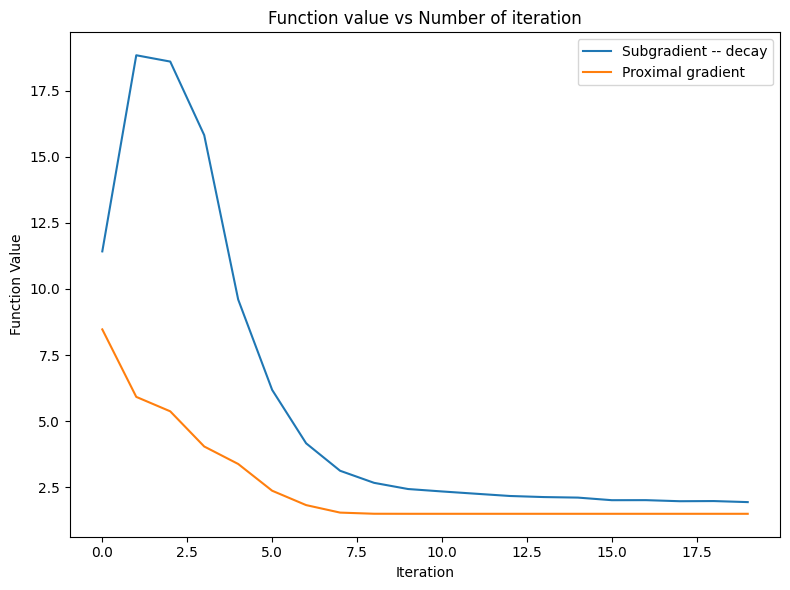

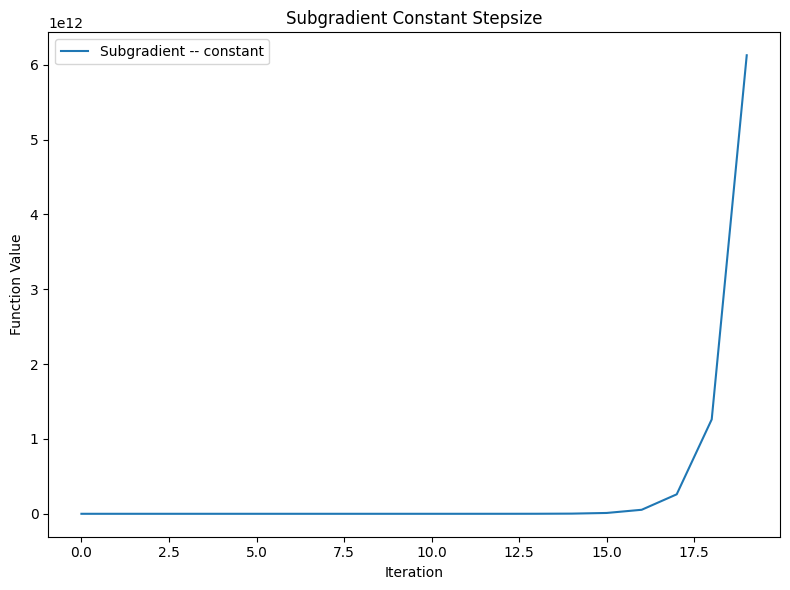

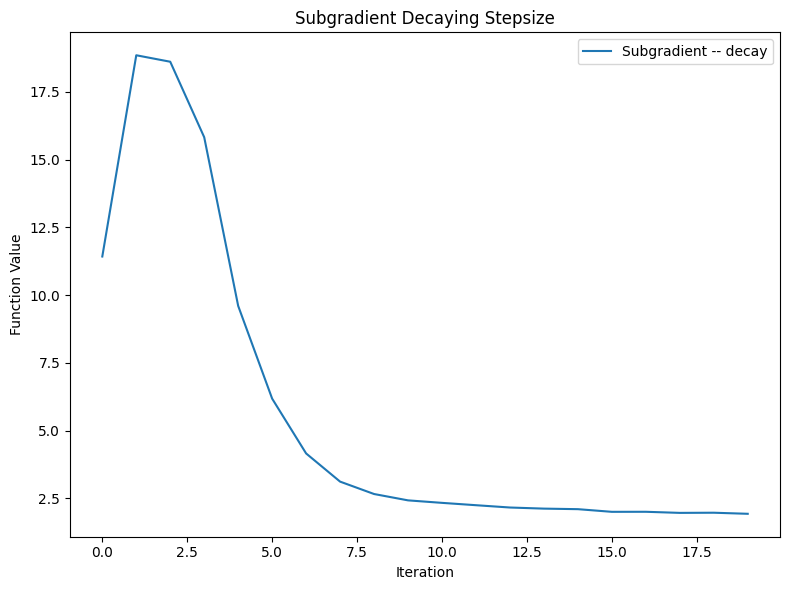

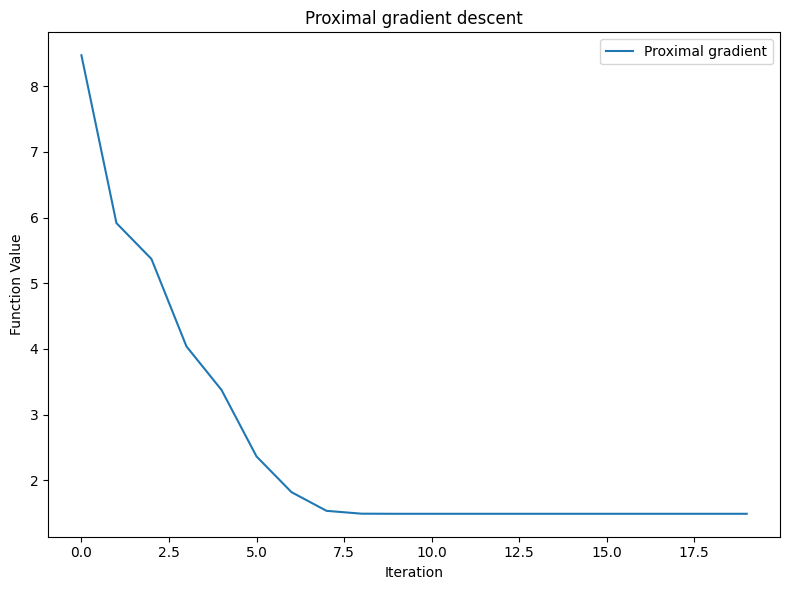

In [7]:
import matplotlib.pyplot as plt


# Set random seed for reproducibility
torch.manual_seed(0)

# Generate synthetic data
n = 500
d = 500
s = 5
mu = 2
sigma = 1
X, y, beta_true = generate_sparse_linear_data(n, d, s, mu, sigma)

# Convert data to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
beta_true = torch.tensor(beta_true, dtype=torch.float32)

print("The first 20 entries of the true parameter are:")
print(beta_true[:20].numpy())


# Set algorithm parameters
lambd = 0.1


stepsize = 0.8

max_iter = 20

# Run subgradient descent
beta_init = torch.zeros(d, dtype=torch.float32)

beta_sub_decay, fun_sub_decay = subgradient_descent(X, y, beta_init, lambd, stepsize, max_iter)

beta_sub_const, fun_sub_const = subgradient_descent(X, y, beta_init, lambd, stepsize, max_iter, decay=False)

# Run proximal gradient descent
beta_prox, fun_prox = proximal_gradient_descent(X, y, beta_init, lambd, stepsize, max_iter)


# report results

subgradient_decay_error = torch.norm(beta_sub_decay - beta_true).item()
subgradient_const_error = torch.norm(beta_sub_const - beta_true).item()
proximal_error = torch.norm(beta_prox - beta_true).item()


print("***Subgradient Descent with Decaying Stepsizes***")
print("The first 20 entries of the estimated parameter are:")
print(beta_sub_decay[:20].numpy())
print("Subgradient Descent - Parameter Error: {:.4f}".format(subgradient_decay_error))
print("Iteration\tFunction Value\tAverage Function Value")
for i in range(0, len(fun_sub_decay), 5):
    print("{}\t\t\t{:.4f}".format(i, fun_sub_decay[i]))
    print("\n")

print("***Subgradient Descent with Constant Stepsizes***")
print("The first 20 entries of the estimated parameter are:")
print(beta_sub_const[:20].numpy())
print("Subgradient Descent - Parameter Error: {:.4f}".format(subgradient_const_error))
print("Iteration\tFunction Value\tAverage Function Value")
for i in range(0, len(fun_sub_const), 5):
    print("{}\t\t\t{:.4f}".format(i, fun_sub_const[i]))
    print("\n")


print("***Proximal Gradient Descent***")
print("The first 20 entries of the estimated parameter are:")
print(beta_prox[:20].numpy())
print("Proximal Gradient Descent - Parameter Error: {:.4f}".format(proximal_error))
print("Iteration\tFunction Value")
for i in range(0, len(fun_prox), 5):
    print("{}\t\t\t{:.4f}".format(i, fun_prox[i]))


plt.figure(figsize=(8, 6))
# plt.plot(fun_sub_const, label='Subgradient -- constant')
plt.plot(fun_sub_decay, label='Subgradient -- decay')
plt.plot(fun_prox, label='Proximal gradient')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Function value vs Number of iteration')
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 6))
plt.plot(fun_sub_const, label='Subgradient -- constant')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Subgradient Constant Stepsize')
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 6))
plt.plot(fun_sub_decay, label='Subgradient -- decay')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Subgradient Decaying Stepsize')
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 6))
plt.plot(fun_prox, label='Proximal gradient')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Proximal gradient descent')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import cvxpy as cp
import numpy as np

def lasso_cvxpy(X, y, lambd):
    """
    Solve the Lasso problem using CVXPY.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - lambd: regularization parameter

    Returns:
    - beta_cvx: optimal weight vector of shape (d,)
    - obj_cvx: optimal objective value
    """
    n, d = X.shape

    # Convert PyTorch tensors to NumPy arrays
    X_np = X.numpy()
    y_np = y.numpy()

    # Define the optimization variables
    beta = cp.Variable(d)

    # Define the objective function
    objective = cp.Minimize(0.5 * cp.sum_squares(X_np @ beta - y_np)/n  + lambd * cp.norm(beta, 1))

    # Define the optimization problem
    problem = cp.Problem(objective)

    # Solve the optimization problem
    obj_cvx = problem.solve()

    # Retrieve the optimal weight vector
    beta_cvx = beta.value

    return beta_cvx, obj_cvx


beta_cvx, obj_cvx = lasso_cvxpy(X, y, lambd)

print("The first 20 entries of the cvx estimated parameter are:")
print(beta_cvx[:20])
cvx_error = np.linalg.norm(beta_cvx - beta_true.numpy())
print("CVXPY - Parameter Error: {:.4f}".format(cvx_error))
print(f"Function Value is: {obj_cvx:.4f}")